<a href="https://colab.research.google.com/github/BrishtyDas22/Data_Mining_Paper_Codes/blob/main/5/12/2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost lightgbm xgboost -q
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = "/content/drive/MyDrive/DATA MINING/diabetes_prediction_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape of Dataset:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape of Dataset: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
print("========== Dataset Info ==========")
print(df.info())

print("\n========== Missing Values ==========")
print(df.isnull().sum())

print("\n========== Duplicate Rows ==========")
print("Duplicate Rows:", df.duplicated().sum())

print("\n========== Statistical Summary ==========")
print(df.describe())

print("\n========== Target Class Distribution ==========")
print(df['diabetes'].value_counts())

print("\n========== Percentage Distribution ==========")
print(df['diabetes'].value_counts(normalize=True) * 100)

========== Dataset Info ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

========== Missing Values ==========
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_l

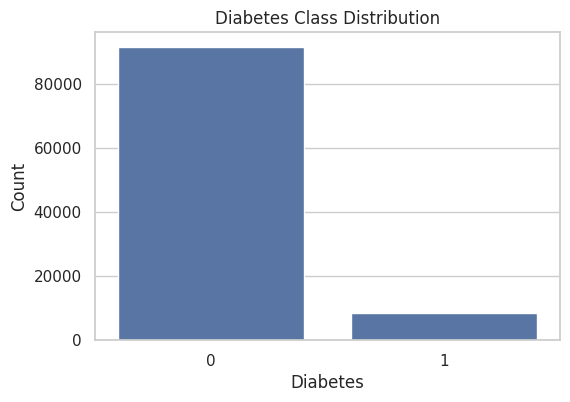

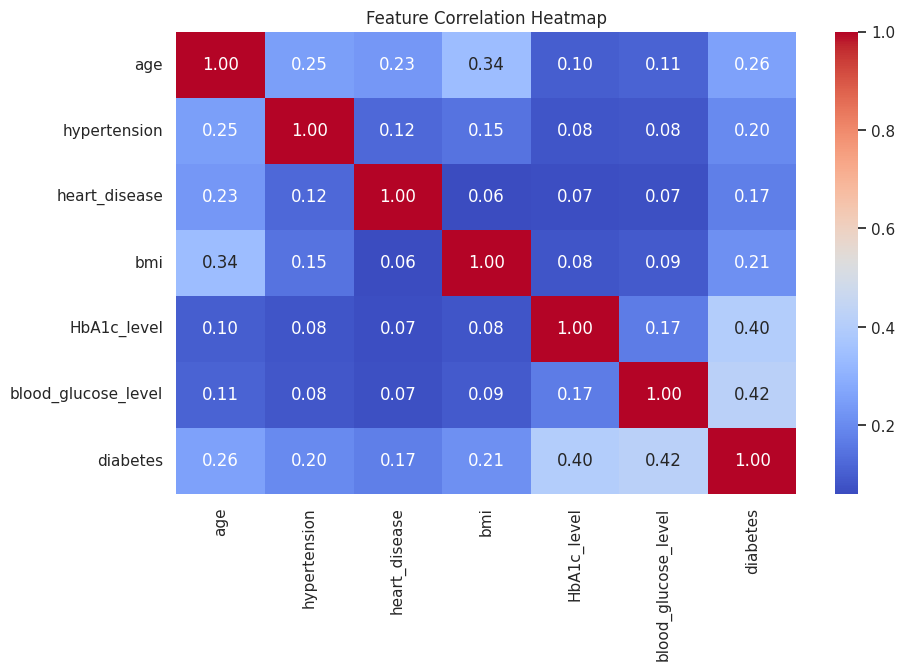

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# Encoding categorical features
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

print("\nEncoded Dataset Preview:")
df.head()

Shape after removing duplicates: (96146, 9)

Encoded Dataset Preview:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [7]:
# Feature and target split
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
diabetes
0    87664
1     8482
Name: count, dtype: int64

After SMOTE:
diabetes
0    87664
1    87664
Name: count, dtype: int64


In [8]:
# 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.30,
    random_state=42,
    stratify=y_resampled
)

# 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (122729, 8)
Validation Shape: (26299, 8)
Testing Shape: (26300, 8)


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

print("\nAll models trained successfully!")


Training Logistic Regression...
Logistic Regression trained successfully!

Training Random Forest...
Random Forest trained successfully!

Training XGBoost...
XGBoost trained successfully!

Training LightGBM...
[LightGBM] [Info] Number of positive: 61365, number of negative: 61364
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1297
[LightGBM] [Info] Number of data points in the train set: 122729, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500004 -> initscore=0.000016
[LightGBM] [Info] Start training from score 0.000016
LightGBM trained successfully!

Training CatBoost...
CatBoost trained successfully!

All models trained successfully!


In [10]:
results = []

print("========== MODEL PERFORMANCE ==========\n")

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print(f"===== {name} =====")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("-----------------------------------\n")

results_df = pd.DataFrame(results)

print("========== FINAL COMPARISON ==========\n")
print(results_df.sort_values(by='Accuracy', ascending=False))

========== MODEL PERFORMANCE ==========

===== Logistic Regression =====
Accuracy  : 0.8814
Precision : 0.8835
Recall    : 0.8786
F1-Score  : 0.8811
-----------------------------------

===== Random Forest =====
Accuracy  : 0.9760
Precision : 0.9753
Recall    : 0.9769
F1-Score  : 0.9761
-----------------------------------

===== XGBoost =====
Accuracy  : 0.9710
Precision : 0.9910
Recall    : 0.9505
F1-Score  : 0.9703
-----------------------------------



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== LightGBM =====
Accuracy  : 0.9792
Precision : 0.9964
Recall    : 0.9618
F1-Score  : 0.9788
-----------------------------------

===== CatBoost =====
Accuracy  : 0.9748
Precision : 0.9960
Recall    : 0.9533
F1-Score  : 0.9742
-----------------------------------

========== FINAL COMPARISON ==========

                 Model  Accuracy  Precision    Recall  F1-Score
3             LightGBM  0.979163   0.996376  0.961825  0.978796
1        Random Forest  0.976046   0.975251  0.976882  0.976066
4             CatBoost  0.974753   0.996027  0.953308  0.974200
2              XGBoost  0.970951   0.991040  0.950494  0.970344
0  Logistic Regression  0.881407   0.883536  0.878631  0.881077


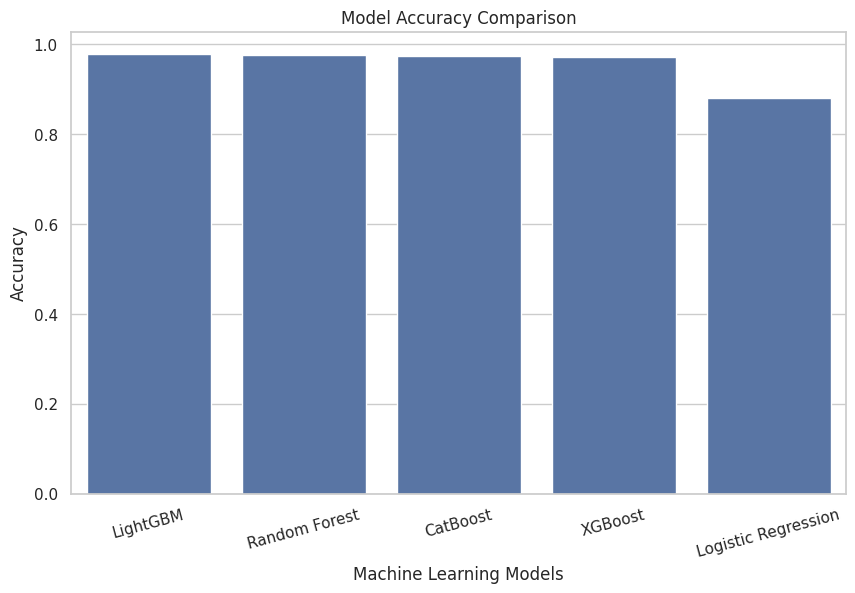

In [11]:
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

In [12]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


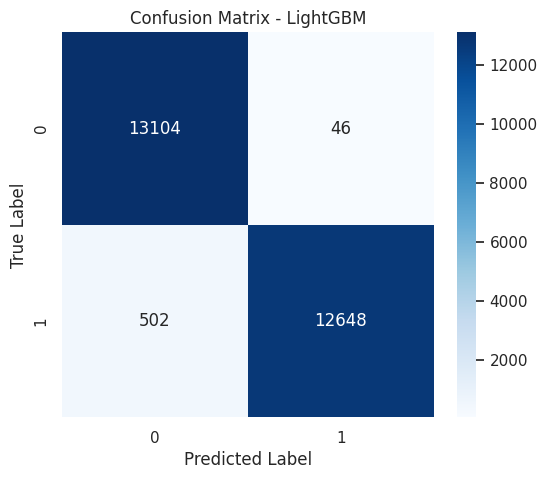

In [13]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AUC Score: 0.9976193352513409


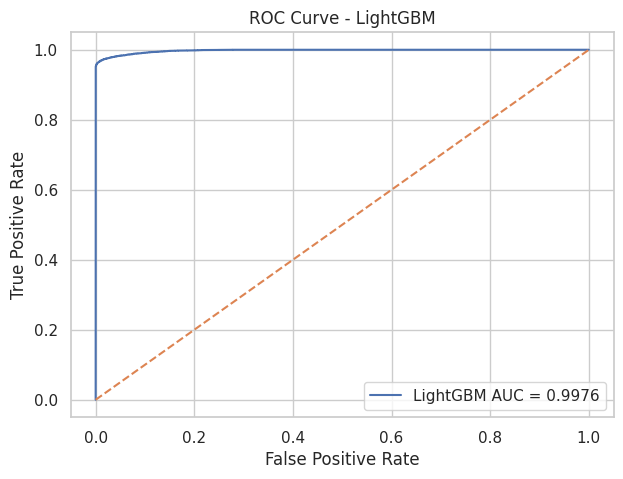

In [14]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'{best_model_name} AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()

plt.show()

               Feature  Importance
1                  age        2652
7  blood_glucose_level        1971
6          HbA1c_level        1901
5                  bmi        1415
4      smoking_history         617
0               gender         176
2         hypertension         156
3        heart_disease         112


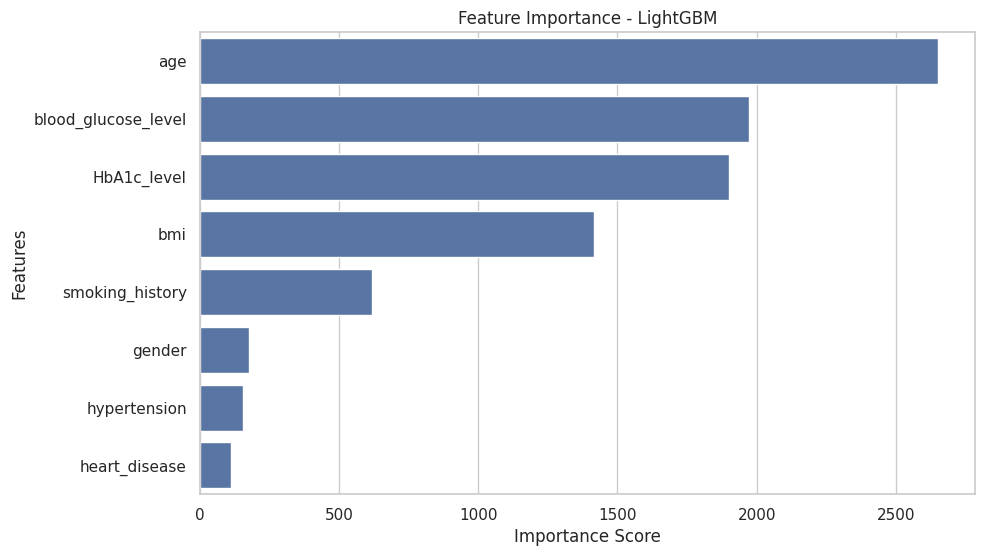

In [15]:
feature_names = X.columns

importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [16]:
risk_probabilities = best_model.predict_proba(X_test)[:, 1]

risk_levels = []

for prob in risk_probabilities:
    if prob < 0.30:
        risk_levels.append("Low Risk")
    elif prob < 0.70:
        risk_levels.append("Medium Risk")
    else:
        risk_levels.append("High Risk")

risk_df = pd.DataFrame({
    'Risk Probability': risk_probabilities,
    'Risk Level': risk_levels
})

print(risk_df.head(20))

print("\n========== RISK LEVEL DISTRIBUTION ==========\n")
print(risk_df['Risk Level'].value_counts())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Risk Probability Risk Level
0           0.000008   Low Risk
1           0.999958  High Risk
2           0.000026   Low Risk
3           0.999972  High Risk
4           0.999994  High Risk
5           0.999963  High Risk
6           0.107387   Low Risk
7           0.000020   Low Risk
8           0.999974  High Risk
9           0.913707  High Risk
10          0.000024   Low Risk
11          0.000036   Low Risk
12          0.002210   Low Risk
13          0.000023   Low Risk
14          0.000011   Low Risk
15          0.989014  High Risk
16          0.999987  High Risk
17          0.057951   Low Risk
18          0.000030   Low Risk
19          0.999981  High Risk

========== RISK LEVEL DISTRIBUTION ==========

Risk Level
Low Risk       13088
High Risk      12500
Medium Risk      712
Name: count, dtype: int64


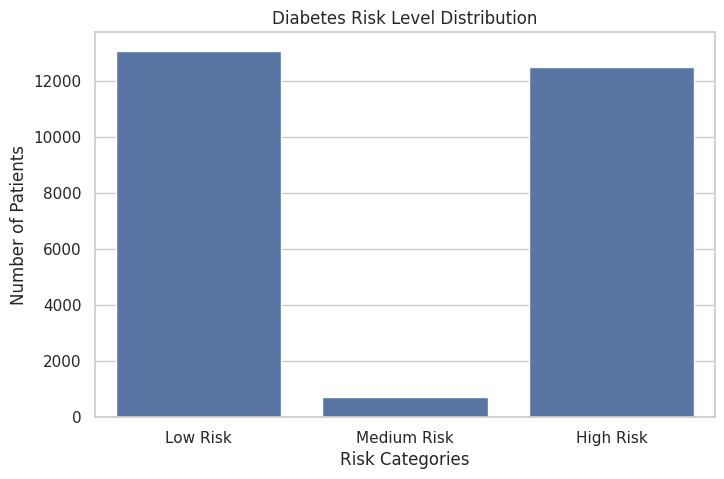

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Risk Level',
    data=risk_df,
    order=['Low Risk', 'Medium Risk', 'High Risk']
)

plt.title("Diabetes Risk Level Distribution")
plt.xlabel("Risk Categories")
plt.ylabel("Number of Patients")

plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


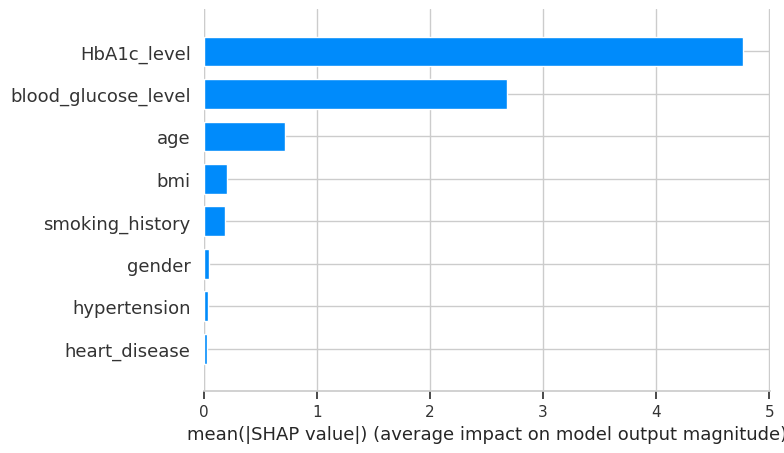

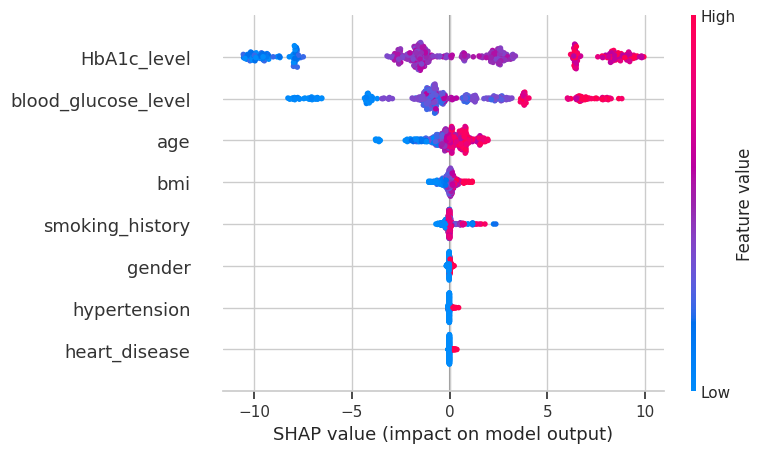

In [18]:
!pip install shap -q

import shap

X_test_full_df = pd.DataFrame(
    X_test,
    columns=X.columns
)

X_sample_full = X_test_full_df.sample(
    n=500,
    random_state=42
)

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_sample_full)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# SHAP Bar Plot
shap.summary_plot(
    shap_values_class1,
    X_sample_full,
    plot_type="bar"
)

# SHAP Beeswarm Plot
shap.summary_plot(
    shap_values_class1,
    X_sample_full
)

In [19]:
novelty_summary = pd.DataFrame({
    "Component": [
        "Class Imbalance Handling",
        "Comparative ML Modeling",
        "Best Model Selection",
        "Risk Stratification",
        "Explainable AI"
    ],
    "Method Used": [
        "SMOTE",
        "LR, RF, XGBoost, LightGBM, CatBoost",
        best_model_name,
        "Low / Medium / High Risk based on probability",
        "SHAP Explainability"
    ],
    "Purpose": [
        "Balance diabetic and non-diabetic classes",
        "Compare multiple machine learning algorithms",
        "Select highest performing model",
        "Convert binary prediction into clinical risk level",
        "Interpret feature impact on diabetes prediction"
    ]
})

novelty_summary

,Component,Method Used,Purpose
0,Class Imbalance Handling,SMOTE,Balance diabetic and non-diabetic classes
1,Comparative ML Modeling,"LR, RF, XGBoost, LightGBM, CatBoost",Compare multiple machine learning algorithms
2,Best Model Selection,LightGBM,Select highest performing model
3,Risk Stratification,Low / Medium / High Risk based on probability,Convert binary prediction into clinical risk l...
4,Explainable AI,SHAP Explainability,Interpret feature impact on diabetes prediction
